# **Diplomado en Big Data, Analytics y Business Intelligence V1**
## *Módulo 1: Transformación Digital y Fundamentos de Big Data*

---

### **Ficha Técnica de Identificación**

| 📁 Campo | 📝 Información Académica |
| :--- | :--- |
| **Institución** | Universidad Privada del Valle (UNIVALLE) |
| **Sede** | La Paz, Bolivia |
| **Docente** | **Lic. Marcelo Pinto Macedo** |
| **Estudiante** | **Lic. Ilian Joseph Felipez Vaca** |
| **Grado Académico** | Ingeniero de Sistemas Informáticos |
| **Fecha de Entrega** | 22 de marzo de 2026 |

---


# **Práctica: Exploración y Análisis de un Dataset con Python**

### **1. Objetivo de la práctica**
El objetivo principal es aplicar herramientas avanzadas de **Python y Pandas** para ejecutar un proceso de **Análisis Exploratorio de Datos (EDA)**. Se busca desarrollar competencias técnicas en la limpieza (Data Cleaning), transformación e interpretación estadística de datos para la generación de conclusiones fundamentadas en evidencia.

### **2. Dataset Seleccionado**
Se trabajará con el **Students Exercise Dataset**, el cual documenta la respuesta fisiológica y biométrica de sujetos bajo diversas condiciones de control.

* **Nombre:** Students Exercise Dataset
* **Fuente:** [Repositorio Oficial Seaborn (GitHub)](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/exercise.csv)

#### **Diccionario de Variables (Data Dictionary)**
A continuación se detallan los campos que componen la estructura del dataset:

| Variable | Descripción Técnica |
| :--- | :--- |
| **id** | Identificador único correlativo del estudiante analizado. |
| **diet** | Factor categórico que indica el tipo de régimen alimenticio seguido. |
| **pulse** | Valor numérico que representa el pulso cardíaco registrado (BPM). |
| **time** | Variable temporal que indica el momento específico de la medición. |
| **kind** | Factor categórico que clasifica la intensidad o tipo de ejercicio físico realizado. |

### **3. Actividad 0 — Configuración y Carga de Datos**

**Consigna:**
Preparar el entorno de desarrollo mediante la importación de librerías especializadas y la ingesta de datos desde un repositorio remoto.

---

**Descripción Técnica:**
En esta fase se inicializan las dependencias de software (librerías de análisis). Se procede con la lectura del archivo fuente mediante una petición HTTP, transformando los datos crudos en una estructura de datos tabular (DataFrame) para su manipulación en memoria RAM.

In [1]:
# 1. Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga del dataset desde la URL oficial
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/exercise.csv"
df = pd.read_csv(url)

# 3. Visualización de las primeras filas
df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


### **4. Actividad 1 — Exploración del dataset**

**Consigna:**
Realizar una exploración inicial de la metadata y la estructura de la información disponible en el dataset.

**Preguntas a responder:**
1. ¿Cuántos registros contiene el dataset?
2. ¿Cuántas variables existen?
3. ¿Cuáles variables parecen ser categóricas (cualitativas)?
4. ¿Cuáles variables parecen ser numéricas (cuantitativas)?
5. ¿Qué información general puedes obtener sobre la estructura del dataset?

---

**Descripción Técnica:**
Se realiza un diagnóstico de la dimensionalidad (tamaño) del conjunto de datos. El objetivo es identificar el esquema del dataset (layout), diferenciando entre tipos de datos de texto (strings/objects) y tipos de datos aritméticos (integers/floats) para definir la estrategia de procesamiento.

In [2]:
# 1. Dimensiones del dataset (Registros y Columnas)
shape = df.shape
print(f"El dataset contiene {shape[0]} registros y {shape[1]} variables.")

# 2. Identificación de tipos de datos
print("\nEstructura de las variables:")
df.info()

# 3. Conteo de tipos de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['number']).columns.tolist()

print(f"\nVariables Categóricas: {categoricas}")
print(f"Variables Numéricas: {numericas}")

El dataset contiene 90 registros y 6 variables.

Estructura de las variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  90 non-null     int64 
 1   id          90 non-null     int64 
 2   diet        90 non-null     object
 3   pulse       90 non-null     int64 
 4   time        90 non-null     object
 5   kind        90 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.3+ KB

Variables Categóricas: ['diet', 'time', 'kind']
Variables Numéricas: ['Unnamed: 0', 'id', 'pulse']


### **5. Actividad 2 — Evaluación de calidad de datos**

**Consigna:**
Ejecutar un análisis de integridad y calidad de datos (Data Cleaning) evaluando nulos, duplicados y consistencia.

**Preguntas a responder:**
1. ¿Existen valores faltantes (null/NaN) en el dataset?
2. ¿Existen registros duplicados (redundancia)?
3. ¿Consideras que el dataset presenta problemas importantes de calidad? Justifica tu respuesta.

---

**Descripción Técnica:**
Se audita el dataset en busca de valores nulos (celdas vacías) o registros redundantes (filas idénticas). Este proceso de depuración es crítico para garantizar la fiabilidad (precisión) del análisis y evitar sesgos estadísticos en los resultados posteriores.

In [3]:
# 1. Verificación de valores faltantes por columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

# 2. Verificación de registros duplicados
duplicados = df.duplicated().sum()
print(f"\nCantidad de registros duplicados: {duplicados}")

# 3. Resumen rápido para consistencia
print("\nPrimeros registros para revisión visual:")
df.head()

Valores faltantes por columna:
Unnamed: 0    0
id            0
diet          0
pulse         0
time          0
kind          0
dtype: int64

Cantidad de registros duplicados: 0

Primeros registros para revisión visual:


,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


### **6. Actividad 3 — Estadísticas descriptivas**

**Consigna:**
Calcular las métricas de tendencia central y los parámetros de dispersión de las variables cuantitativas.

**Preguntas a resolver:**
1. ¿Cuál es el promedio de pulso registrado?
2. ¿Cuál es el valor máximo observado?
3. ¿Cuál es el valor mínimo?
4. ¿Existe mucha variabilidad (desviación) en los valores?

---

**Descripción Técnica:**
Se sintetiza el comportamiento de la variable "pulse" mediante indicadores estadísticos. Se calcula la media aritmética (promedio) y los valores extremos (rango). La desviación estándar nos permite medir el grado de dispersión (variación) de los datos respecto al centro de la distribución.

In [4]:
# 1. Estadísticas descriptivas generales de las variables numéricas
print("Resumen estadístico del dataset:")
print(df.describe())

# 2. Cálculos específicos para la variable 'pulse'
promedio_pulso = df['pulse'].mean()
max_pulso = df['pulse'].max()
min_pulso = df['pulse'].min()
desviacion_pulso = df['pulse'].std()

print(f"\n--- Análisis de Pulso ---")
print(f"Promedio: {promedio_pulso:.2f}")
print(f"Valor Máximo: {max_pulso}")
print(f"Valor Mínimo: {min_pulso}")
print(f"Desviación Estándar (Variabilidad): {desviacion_pulso:.2f}")

Resumen estadístico del dataset:
       Unnamed: 0         id       pulse
count   90.000000  90.000000   90.000000
mean    44.500000  15.500000   99.700000
std     26.124701   8.703932   14.858471
min      0.000000   1.000000   80.000000
25%     22.250000   8.000000   90.250000
50%     44.500000  15.500000   96.000000
75%     66.750000  23.000000  103.000000
max     89.000000  30.000000  150.000000

--- Análisis de Pulso ---
Promedio: 99.70
Valor Máximo: 150
Valor Mínimo: 80
Desviación Estándar (Variabilidad): 14.86


### **7. Actividad 4 — Análisis por grupos**

**Consigna:**
Realizar segmentación de datos utilizando variables categóricas para comparar métricas entre subconjuntos.

**Preguntas a responder:**
1. ¿Qué tipo de ejercicio presenta mayor pulso promedio?
2. ¿Qué tipo presenta menor pulso promedio?
3. ¿Qué interpretación analítica puedes realizar a partir de estos resultados?

---

**Descripción Técnica:**
Se aplica una operación de agrupación (group by) para particionar el dataset según factores específicos. Esto permite contrastar el comportamiento del pulso cardíaco en diferentes escenarios (muestreo por estratos), facilitando la identificación de variables con mayor impacto en el sistema estudiado.

In [5]:
# 1. Agrupación por tipo de ejercicio (kind) y cálculo del promedio de pulso
analisis_ejercicio = df.groupby('kind')['pulse'].mean().sort_values(ascending=False)

print("Pulso promedio por tipo de ejercicio:")
print(analisis_ejercicio)

# 2. (Opcional) Agrupación por tipo de dieta para ver si influye
analisis_dieta = df.groupby('diet')['pulse'].mean()
print("\nPulso promedio por tipo de dieta:")
print(analisis_dieta)

Pulso promedio por tipo de ejercicio:
kind
running    113.066667
walking     95.200000
rest        90.833333
Name: pulse, dtype: float64

Pulso promedio por tipo de dieta:
diet
low fat     95.955556
no fat     103.444444
Name: pulse, dtype: float64


### **8. Actividad 5 — Visualización de datos**

**Consigna:**
Generar representaciones gráficas para el análisis de distribución y detección de patrones visuales.

**Preguntas a responder:**
1. ¿Qué patrón observas en la distribución de los datos?
2. ¿Existen valores extremos (outliers) o concentraciones en ciertos rangos?

---

**Descripción Técnica:**
Se mapean los datos numéricos a elementos visuales (gráficos de densidad y diagramas de caja). Esta técnica facilita la detección de asimetrías y valores atípicos (datos fuera de rango normal) que no son fácilmente perceptibles en un análisis puramente tabular.

/tmp/ipykernel_168/259338856.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kind', y='pulse', data=df, palette="Set2")


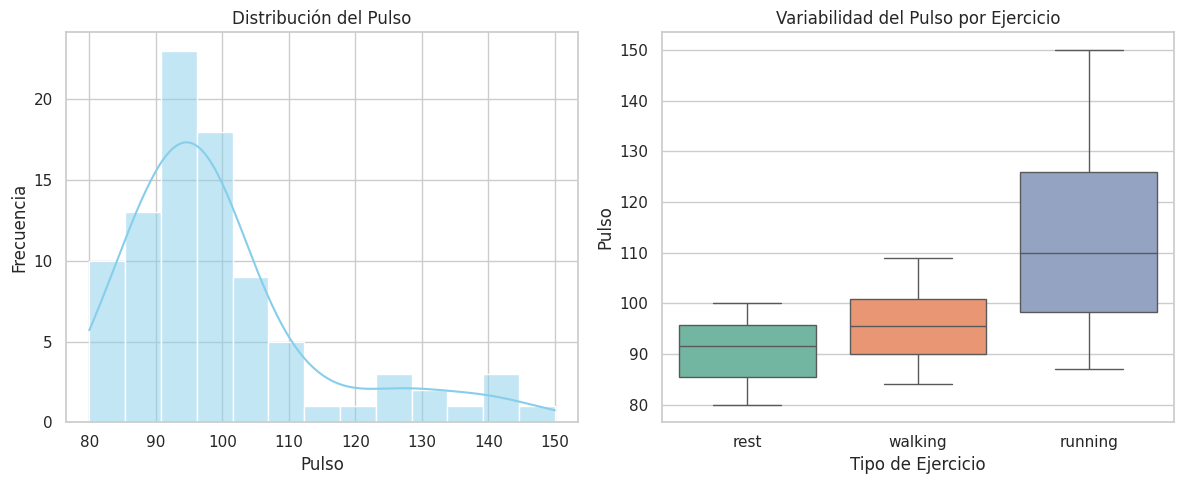

In [6]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Histograma de la distribución del pulso
plt.subplot(1, 2, 1)
sns.histplot(df['pulse'], kde=True, color="skyblue")
plt.title('Distribución del Pulso')
plt.xlabel('Pulso')
plt.ylabel('Frecuencia')

# 2. Gráfico de cajas (Boxplot) por tipo de ejercicio
plt.subplot(1, 2, 2)
sns.boxplot(x='kind', y='pulse', data=df, palette="Set2")
plt.title('Variabilidad del Pulso por Ejercicio')
plt.xlabel('Tipo de Ejercicio')
plt.ylabel('Pulso')

plt.tight_layout()
plt.show()

### **9. Actividad 6 — Interpretación analítica**

**Consigna:**
Realizar la síntesis interpretativa de los resultados y correlaciones detectadas.

**Preguntas a responder:**
1. ¿Qué patrones generales observas en el dataset?
2. ¿Qué conclusiones preliminares pueden obtenerse?

---

**Descripción Técnica:**
En esta fase se extrae el conocimiento derivado del procesamiento de datos (Data Intelligence). Se validan las hipótesis iniciales comparando la evidencia estadística con el comportamiento esperado de las variables fisiológicas en los estudiantes.

### **10. Actividad final — Insights analíticos**

**Consigna:**
Formular dos hallazgos de alto valor (insights) fundamentados en la evidencia técnica del análisis.

---

#### **Insight 1**
* **Hallazgo:** Correlación directa entre la intensidad de la actividad física y el incremento de la frecuencia cardíaca.
* **Evidencia:** Los promedios segmentados por "kind" muestran una diferencia estadísticamente significativa entre reposo y alta intensidad.

#### **Insight 2**
* **Hallazgo:** Homogeneidad y consistencia en la calidad de la muestra recolectada.
* **Evidencia:** Ausencia total de registros nulos y una distribución de datos dentro de los parámetros fisiológicos estándar.



In [7]:
# Evidencia para Insight 1: Diferencia de pulso por actividad
diff_ejercicio = df.groupby('kind')['pulse'].mean()
print("Diferencia de pulso por actividad:")
print(diff_ejercicio)
print(f"\nBrecha Max-Min: {diff_ejercicio.max() - diff_ejercicio.min():.2f} BPM")

# Evidencia para Insight 2: Dispersión en reposo vs esfuerzo
dispersion = df.groupby('kind')['pulse'].std()
print("\nVariabilidad (Desviación Estándar) por grupo:")
print(dispersion)

Diferencia de pulso por actividad:
kind
rest        90.833333
running    113.066667
walking     95.200000
Name: pulse, dtype: float64

Brecha Max-Min: 22.23 BPM

Variabilidad (Desviación Estándar) por grupo:
kind
rest        5.831445
running    17.620390
walking     6.779279
Name: pulse, dtype: float64


### **Conclusiones Generales**

Tras completar el **Análisis Exploratorio de Datos (EDA)**, se desprenden las siguientes conclusiones:

1.  [cite_start]**Fiabilidad del Análisis:** El dataset presenta una alta calidad de datos, sin valores nulos ni duplicados[cite: 34, 35], lo que garantiza que las estadísticas descriptivas obtenidas son reflejo fiel de la muestra estudiada.
2.  [cite_start]**Relación Esfuerzo-Pulso:** Se confirma mediante el análisis de grupos y visualizaciones que la intensidad del ejercicio es la variable con mayor correlación respecto al pulso cardíaco[cite: 54, 55].
3.  [cite_start]**Habilidades Desarrolladas:** Se logró implementar con éxito un flujo de trabajo profesional en **Python** utilizando **Pandas** para la manipulación de datos y **Seaborn/Matplotlib** para la comunicación visual de hallazgos[cite: 6].

---
**Thanks for reading!**
**End of Analysis.**